In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/churn.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.shape

(10000, 14)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [12]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [13]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [14]:
df["Churn_Status"] = df["Exited"].map({
    0: "Stayed",
    1: "Churned"
})

df["CreditScore"].describe()


count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

In [15]:
churn_rate = df["Exited"].mean() * 100
churn_rate

np.float64(20.369999999999997)

In [16]:
df.groupby("Churn_Status")[[
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "EstimatedSalary"
]].mean()


,CreditScore,Age,Tenure,Balance,EstimatedSalary
Churn_Status,,,,,
Churned,645.351497,44.837997,4.932744,91108.539337,101465.677531
Stayed,651.853196,37.408389,5.033279,72745.296779,99738.391772


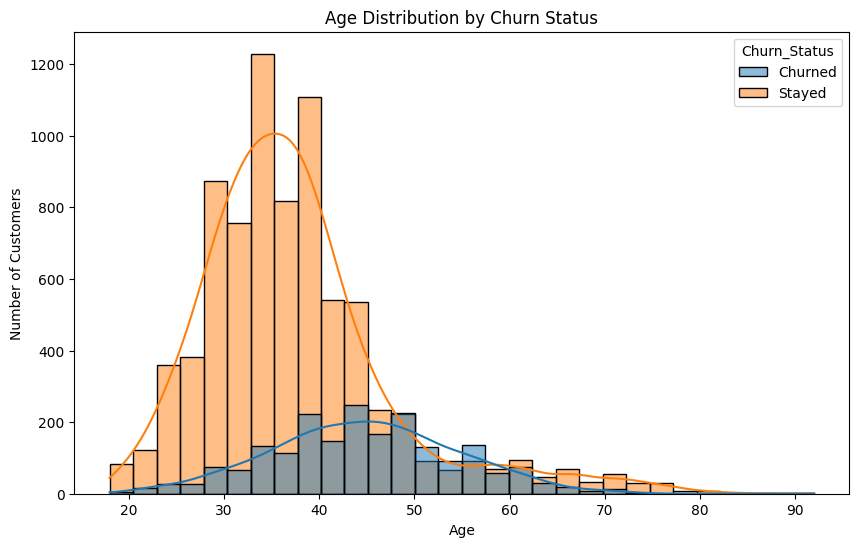

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Age",
    hue="Churn_Status",
    bins=30,
    kde=True
)

plt.title("Age Distribution by Churn Status")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.savefig("visuals/Age Distribution by Churn Status.png", dpi=300)
plt.show()


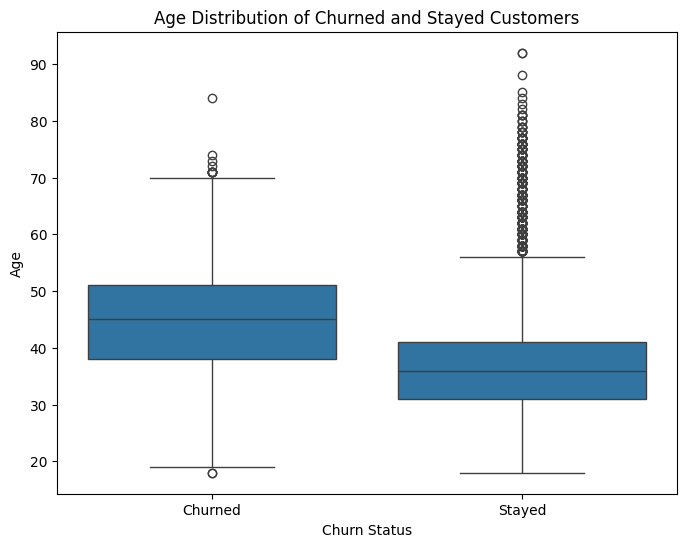

In [24]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Churn_Status",
    y="Age"
)

plt.title("Age Distribution of Churned and Stayed Customers")
plt.xlabel("Churn Status")
plt.ylabel("Age")
plt.savefig("visuals/Age Distribution of Churned and Stayed Customerss.png", dpi=300)
plt.show()


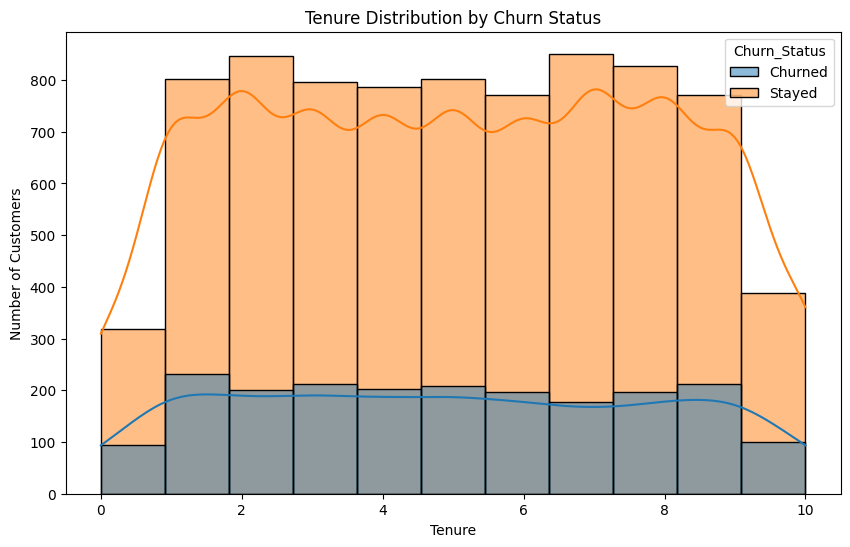

In [25]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Tenure",
    hue="Churn_Status",
    bins=11,
    kde=True
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")

plt.savefig("visuals/tenure_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

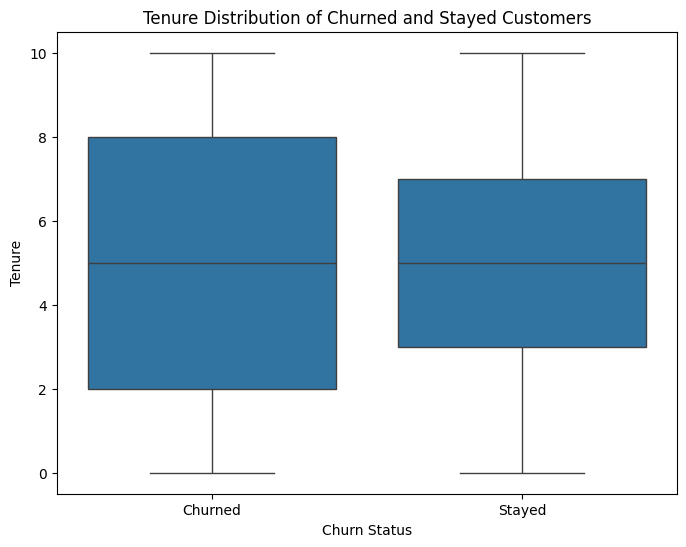

In [26]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Churn_Status",
    y="Tenure"
)

plt.title("Tenure Distribution of Churned and Stayed Customers")
plt.xlabel("Churn Status")
plt.ylabel("Tenure")

plt.savefig("visuals/tenure_churn_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

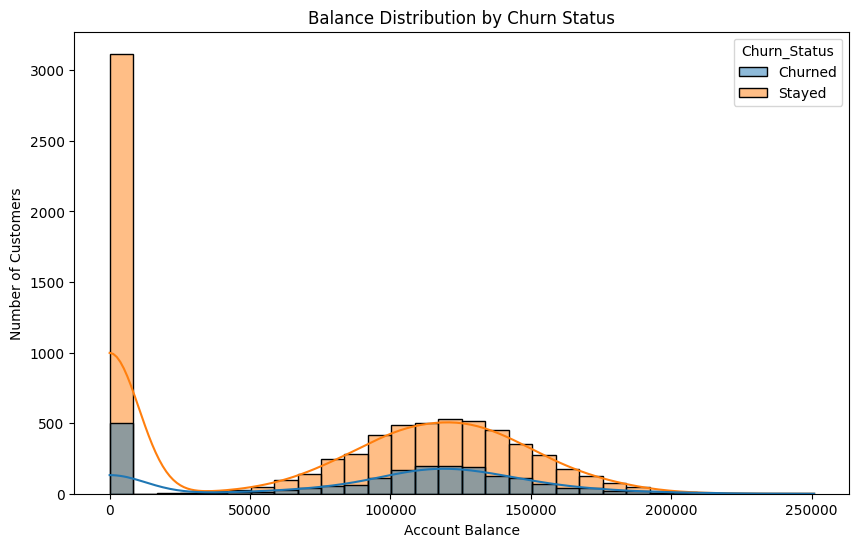

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Balance",
    hue="Churn_Status",
    bins=30,
    kde=True
)

plt.title("Balance Distribution by Churn Status")
plt.xlabel("Account Balance")
plt.ylabel("Number of Customers")

plt.savefig("visuals/balance_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

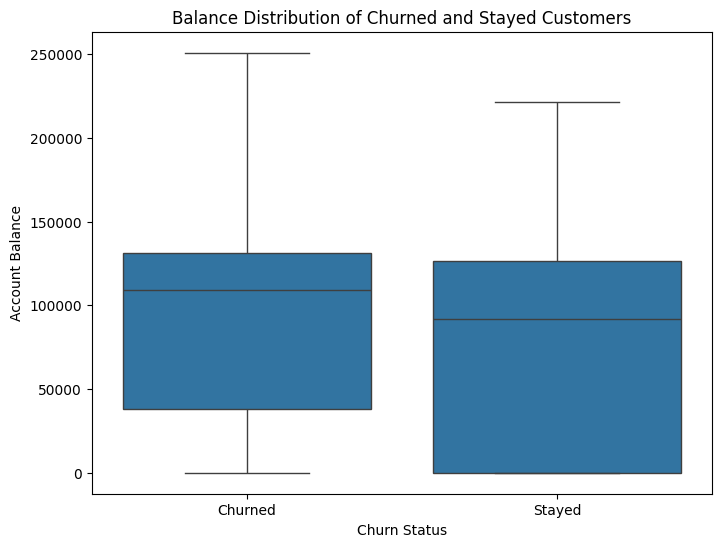

In [28]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Churn_Status",
    y="Balance"
)

plt.title("Balance Distribution of Churned and Stayed Customers")
plt.xlabel("Churn Status")
plt.ylabel("Account Balance")

plt.savefig("visuals/balance_churn_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

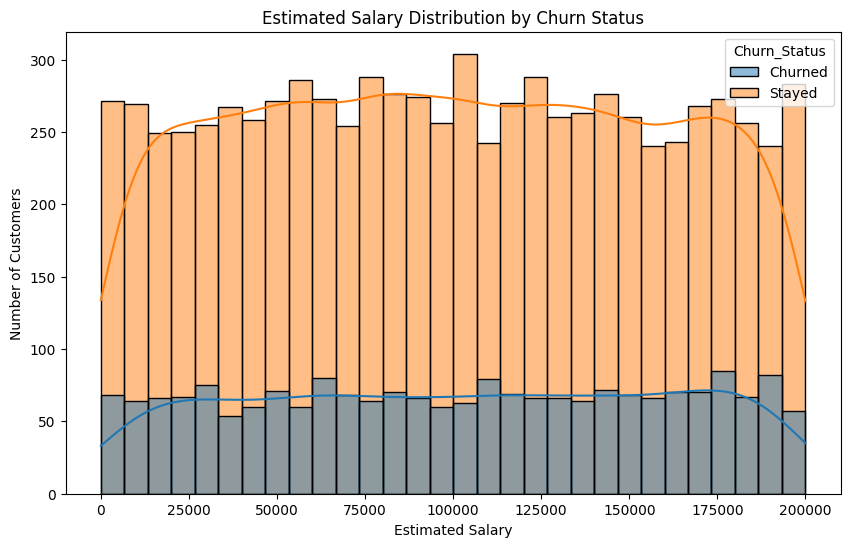

In [29]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="EstimatedSalary",
    hue="Churn_Status",
    bins=30,
    kde=True
)

plt.title("Estimated Salary Distribution by Churn Status")
plt.xlabel("Estimated Salary")
plt.ylabel("Number of Customers")

plt.savefig("visuals/salary_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

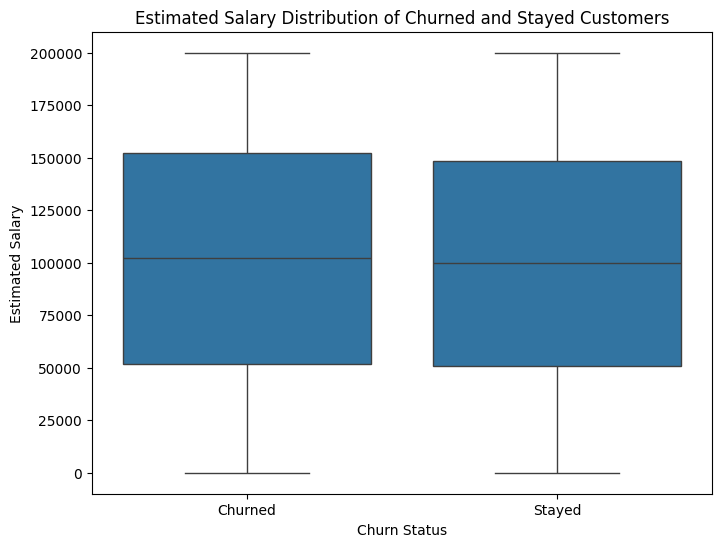

In [30]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Churn_Status",
    y="EstimatedSalary"
)

plt.title("Estimated Salary Distribution of Churned and Stayed Customers")
plt.xlabel("Churn Status")
plt.ylabel("Estimated Salary")

plt.savefig("visuals/salary_churn_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

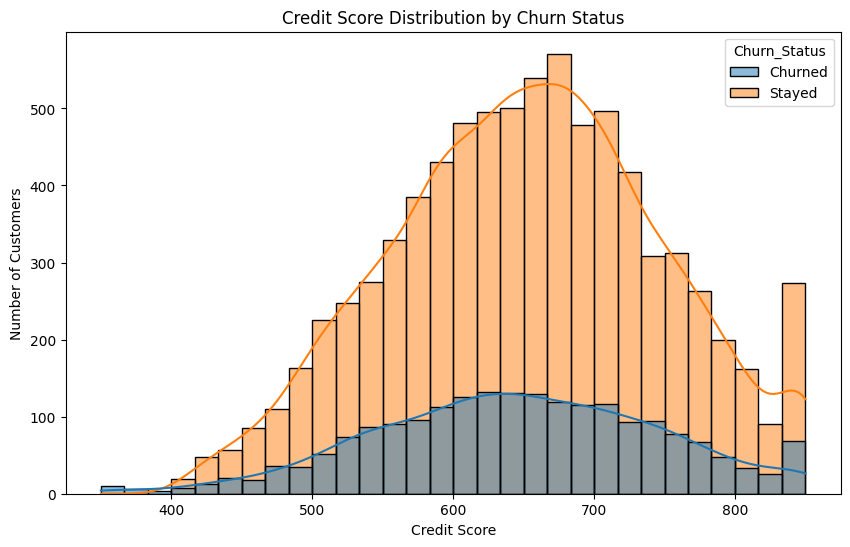

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="CreditScore",
    hue="Churn_Status",
    bins=30,
    kde=True
)

plt.title("Credit Score Distribution by Churn Status")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.savefig("visuals/credit_score_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

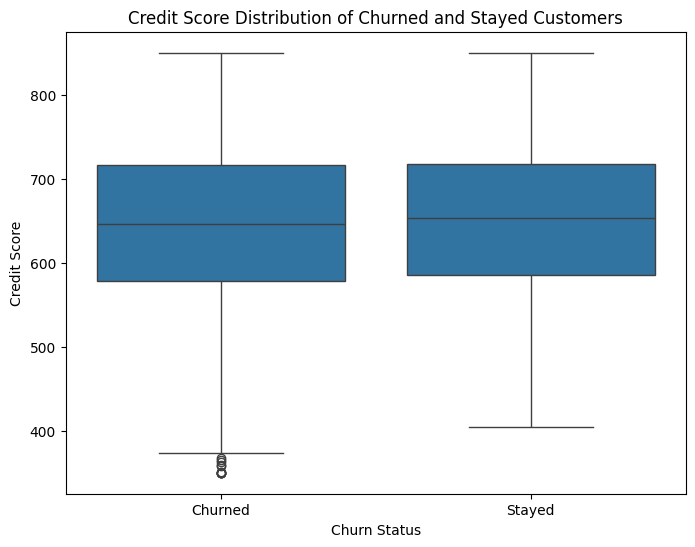

In [32]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Churn_Status",
    y="CreditScore"
)

plt.title("Credit Score Distribution of Churned and Stayed Customers")
plt.xlabel("Churn Status")
plt.ylabel("Credit Score")

plt.savefig("visuals/credit_score_churn_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

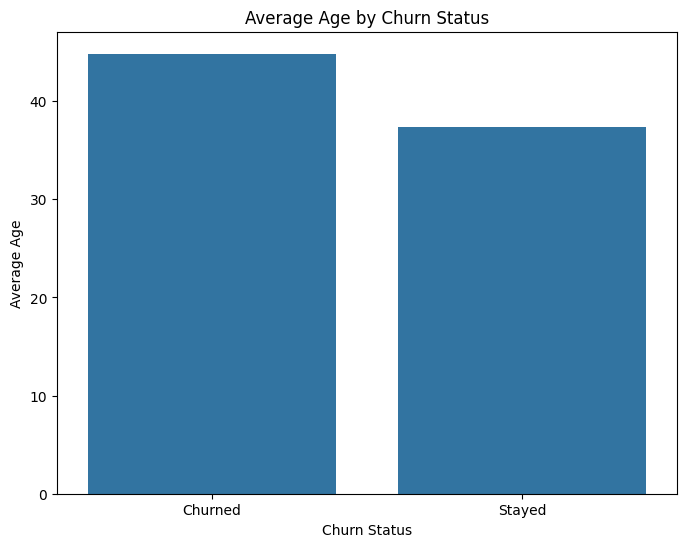

In [33]:
age_churn = df.groupby("Churn_Status")["Age"].mean()

plt.figure(figsize=(8, 6))

sns.barplot(
    x=age_churn.index,
    y=age_churn.values
)

plt.title("Average Age by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Age")

plt.savefig("visuals/churn_vs_age.png", dpi=300, bbox_inches="tight")

plt.show()

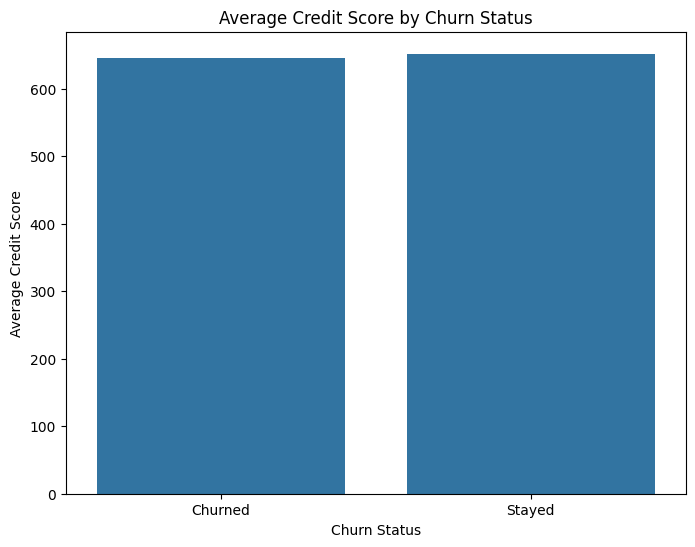

In [34]:
credit_churn = df.groupby("Churn_Status")["CreditScore"].mean()

plt.figure(figsize=(8, 6))

sns.barplot(
    x=credit_churn.index,
    y=credit_churn.values
)

plt.title("Average Credit Score by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Credit Score")

plt.savefig("visuals/churn_vs_credit_score.png", dpi=300, bbox_inches="tight")

plt.show()

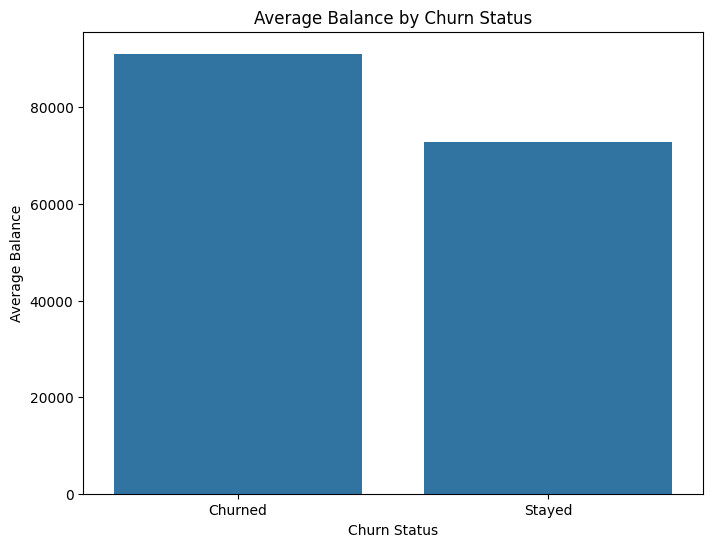

In [35]:
balance_churn = df.groupby("Churn_Status")["Balance"].mean()

plt.figure(figsize=(8, 6))

sns.barplot(
    x=balance_churn.index,
    y=balance_churn.values
)

plt.title("Average Balance by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Balance")

plt.savefig("visuals/churn_vs_balance.png", dpi=300, bbox_inches="tight")

plt.show()

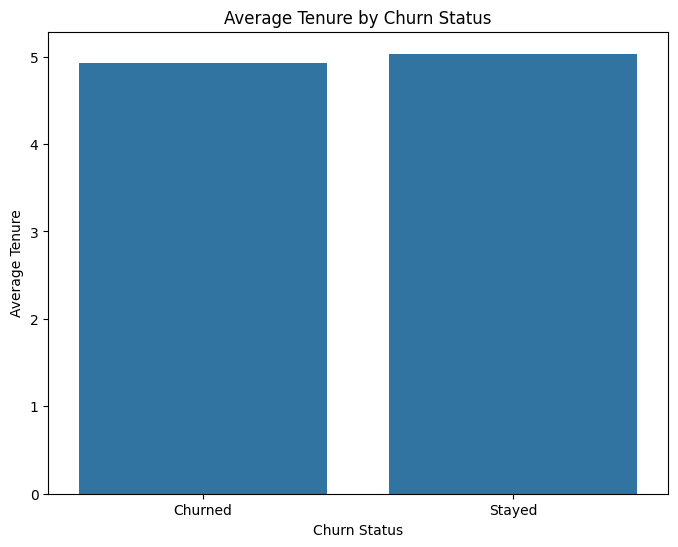

In [36]:
tenure_churn = df.groupby("Churn_Status")["Tenure"].mean()

plt.figure(figsize=(8, 6))

sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values
)

plt.title("Average Tenure by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Tenure")

plt.savefig("visuals/churn_vs_tenure.png", dpi=300, bbox_inches="tight")

plt.show()

In [37]:
gender_churn = df.groupby("Gender")["Exited"].mean() * 100

gender_churn

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

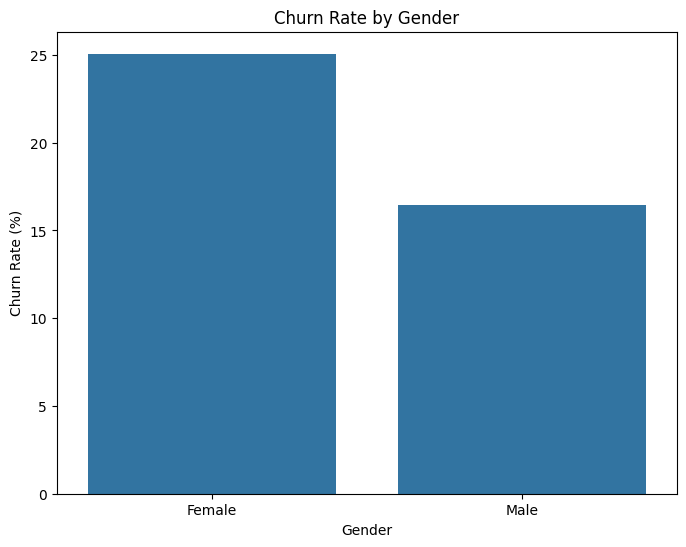

In [38]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=gender_churn.index,
    y=gender_churn.values
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.savefig("visuals/churn_by_gender.png", dpi=300, bbox_inches="tight")

plt.show()

In [39]:
geography_churn = df.groupby("Geography")["Exited"].mean() * 100

geography_churn

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

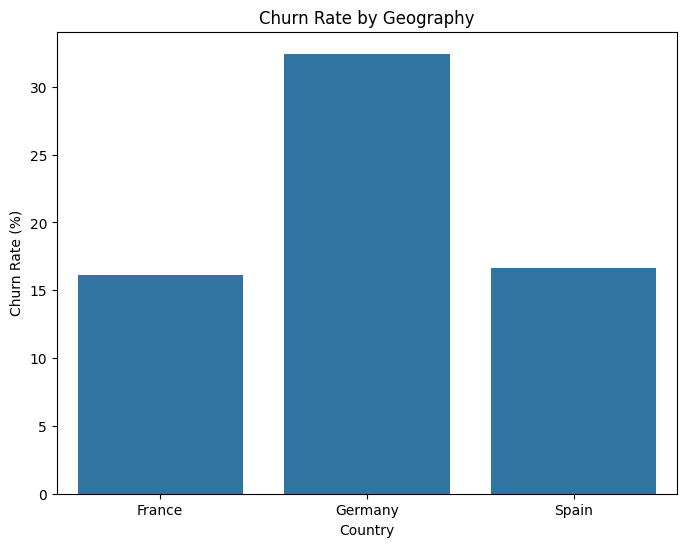

In [40]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=geography_churn.index,
    y=geography_churn.values
)

plt.title("Churn Rate by Geography")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")

plt.savefig("visuals/churn_by_geography.png", dpi=300, bbox_inches="tight")

plt.show()

In [42]:
gender_churn


Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

In [43]:
geography_churn

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

In [44]:
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

corr

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


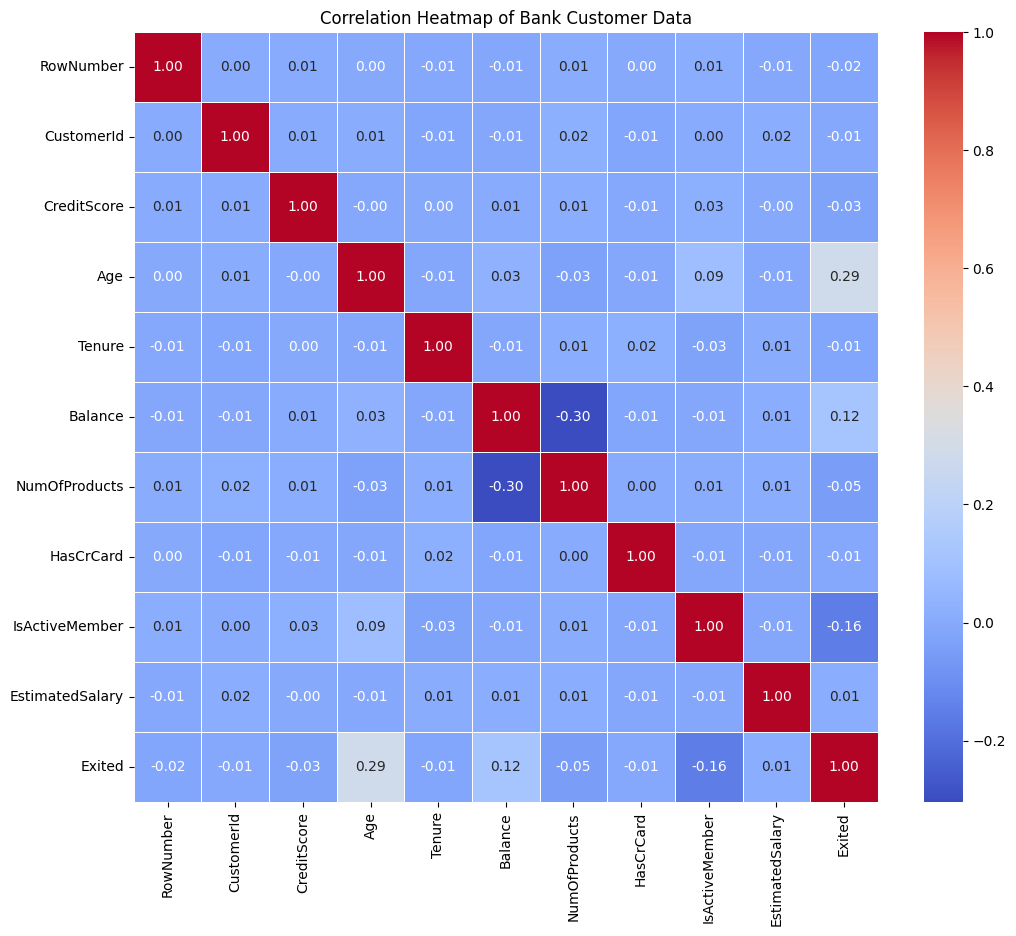

In [45]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Bank Customer Data")

plt.savefig("visuals/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [46]:
active_churn = df.groupby("IsActiveMember")["Exited"].mean() * 100

active_churn

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64

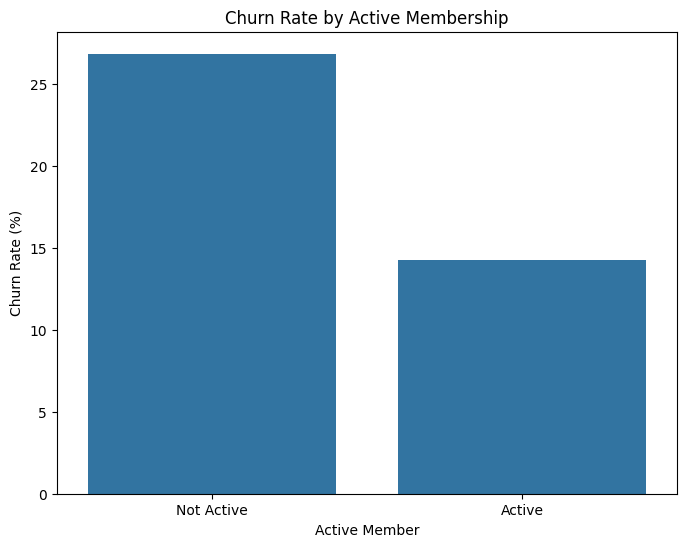

In [47]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=active_churn.index,
    y=active_churn.values
)

plt.title("Churn Rate by Active Membership")
plt.xlabel("Active Member")
plt.ylabel("Churn Rate (%)")

plt.xticks(
    [0, 1],
    ["Not Active", "Active"]
)

plt.savefig("visuals/churn_by_active_membership.png", dpi=300, bbox_inches="tight")

plt.show()

In [48]:
product_churn = df.groupby("NumOfProducts")["Exited"].mean() * 100

product_churn

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64

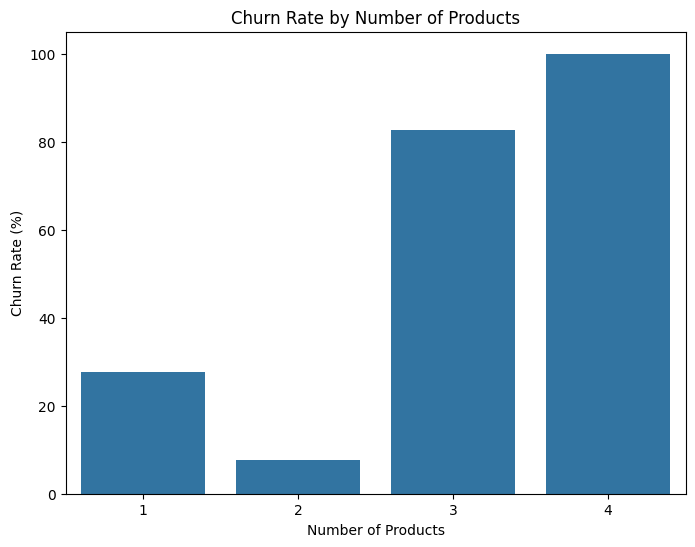

In [49]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=product_churn.index,
    y=product_churn.values
)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.savefig("visuals/churn_by_products.png", dpi=300, bbox_inches="tight")

plt.show()

In [50]:
product_counts = df["NumOfProducts"].value_counts().sort_index()

product_counts

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [51]:
product_churn_summary = df.groupby("NumOfProducts")["Exited"].agg(
    Customer_Count="count",
    Churned_Customers="sum",
    Churn_Rate="mean"
)

product_churn_summary["Churn_Rate"] = product_churn_summary["Churn_Rate"] * 100

product_churn_summary

,Customer_Count,Churned_Customers,Churn_Rate
NumOfProducts,,,
1,5084,1409,27.714398
2,4590,348,7.581699
3,266,220,82.706767
4,60,60,100.000000


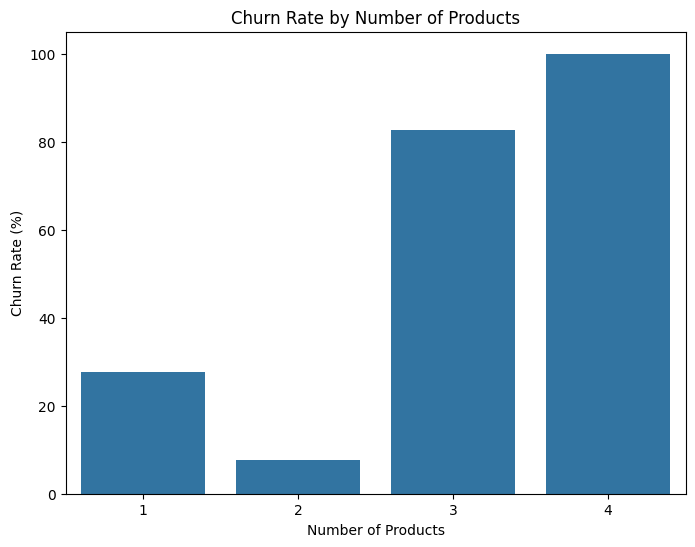

In [54]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=product_churn_summary.index,
    y=product_churn_summary["Churn_Rate"]
)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.savefig("visuals/churn_by_products.png", dpi=300, bbox_inches="tight")

plt.show()

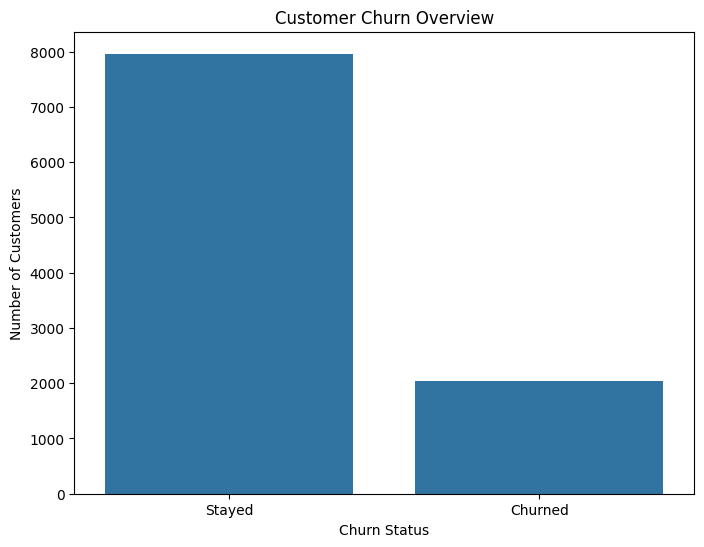

In [55]:
churn_counts = df["Churn_Status"].value_counts()

plt.figure(figsize=(8, 6))

sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Customer Churn Overview")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.savefig("visuals/churn_overview.png", dpi=300, bbox_inches="tight")

plt.show()

In [57]:
product_counts = df["NumOfProducts"].value_counts().sort_index()

product_counts

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [58]:
product_churn_summary = df.groupby("NumOfProducts")["Exited"].agg(
    Customer_Count="count",
    Churned_Customers="sum",
    Churn_Rate="mean"
)

product_churn_summary["Churn_Rate"] = product_churn_summary["Churn_Rate"] * 100

product_churn_summary

,Customer_Count,Churned_Customers,Churn_Rate
NumOfProducts,,,
1,5084,1409,27.714398
2,4590,348,7.581699
3,266,220,82.706767
4,60,60,100.000000


## Key Insights

### 1. Overall Churn

- The dataset contains **10,000 customers**.
- **7,963 customers stayed**, while **2,037 customers churned**.
- The overall customer churn rate is **20.37%**.

### 2. Age and Churn

- Churned customers have an average age of **44.84 years**.
- Stayed customers have an average age of **37.41 years**.
- The age distribution and boxplot show that churned customers are generally older.
- Age has the strongest positive numerical correlation with churn at **0.29**.

**Insight:** Age appears to be one of the more important factors associated with customer churn.

### 3. Balance and Churn

- Churned customers have an average balance of **91,108.54**.
- Stayed customers have an average balance of **72,745.30**.
- Customers who churned generally show higher account balances.

**Insight:** Higher account balance has a positive relationship with customer churn, although the correlation is relatively weak at **0.12**.

### 4. Active Membership and Churn

- Inactive customers have a churn rate of **26.85%**.
- Active customers have a churn rate of **14.27%**.
- The difference between the two groups is **12.58 percentage points**.
- `IsActiveMember` has a negative correlation with churn of **-0.16**.

**Insight:** Customer activity is an important factor associated with retention. Active members have a substantially lower churn rate.

### 5. Geography and Churn

- France has a churn rate of **16.15%**.
- Spain has a churn rate of **16.67%**.
- Germany has the highest churn rate at **32.44%**.

**Insight:** Germany shows a significantly higher churn rate than France and Spain, making geography an important area for further investigation.

### 6. Gender and Churn

- Female customers have a churn rate of **25.07%**.
- Male customers have a churn rate of **16.46%**.

**Insight:** Female customers have a higher churn rate than male customers in this dataset.

### 7. Credit Score and Churn

- Average credit score of churned customers: **645.35**.
- Average credit score of stayed customers: **651.85**.
- The two distributions overlap considerably.
- Credit Score has a weak correlation with churn of **-0.03**.

**Insight:** Credit Score does not appear to be a strong standalone indicator of customer churn.

### 8. Tenure and Churn

- Average tenure of churned customers: **4.93 years**.
- Average tenure of stayed customers: **5.03 years**.
- The distributions are very similar.
- Tenure has a correlation of only **-0.01** with churn.

**Insight:** Tenure does not appear to be a major factor associated with churn in this dataset.

### 9. Estimated Salary and Churn

- Average estimated salary of churned customers: **101,465.68**.
- Average estimated salary of stayed customers: **99,738.39**.
- The distributions are very similar.
- Estimated Salary has a correlation of only **0.01** with churn.

**Insight:** Estimated Salary does not show a strong relationship with customer churn.

### 10. Number of Products and Churn

| Number of Products | Customers | Churned Customers | Churn Rate |
|---:|---:|---:|---:|
| 1 | 5,084 | 1,409 | 27.71% |
| 2 | 4,590 | 348 | 7.58% |
| 3 | 266 | 220 | 82.71% |
| 4 | 60 | 60 | 100.00% |

- Customers with two products have the lowest churn rate at **7.58%**.
- Customers with one product have a churn rate of **27.71%**.
- Customers with three products have a churn rate of **82.71%**.
- All 60 customers with four products churned.
- The three-product and four-product groups are relatively small, so their extremely high churn rates should be interpreted carefully.

**Insight:** The number of products shows a strong variation in churn rates, with three- and four-product customers showing particularly high churn in this dataset.

## Why Customers Churn

The analysis indicates that customer churn is associated with several customer characteristics and behaviors.

The strongest patterns are related to **age, active membership, geography, balance, gender, and number of products**. Older customers have higher average ages among churned customers, while inactive members have substantially higher churn rates than active members.

Germany has the highest geographical churn rate, while female customers also show a higher churn rate than male customers. Customers with higher balances show a positive relationship with churn.

The number of products also shows a strong variation in churn rates. Customers with two products have the lowest churn rate, while customers with three or four products have very high churn rates. However, the smaller number of customers in these groups means these results should be interpreted with caution.

Credit Score, Tenure, and Estimated Salary show relatively weak relationships with churn.

Overall, the analysis suggests that **customer age, engagement, geography, balance, gender, and product usage are important areas to consider when investigating customer churn**.

## Conclusion

This project analyzed 10,000 bank customers to identify patterns associated with customer churn.

The analysis found an overall churn rate of **20.37%**. Age showed the strongest positive numerical correlation with churn, while active membership showed a negative relationship with churn.

Geography and gender also showed noticeable differences in churn rates, with Germany and female customers having higher churn rates. Balance showed a moderate difference between churned and stayed customers, while Credit Score, Tenure, and Estimated Salary showed relatively weak relationships.

The analysis demonstrates how Exploratory Data Analysis, visualizations, and correlation analysis can be used to identify customer segments and behavioral patterns associated with churn.